## Import Libraries

Import `numpy`, `cv2`, `tensorflow.keras.datasets.mnist`, and `matplotlib.pyplot`.


In [8]:
import numpy as np
import cv2
import tensorflow.keras.datasets.mnist
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## Load MNIST Dataset

Load the MNIST dataset using `tf.keras.datasets.mnist.load_data()`.


In [9]:
mnist = tensorflow.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("MNIST dataset loaded successfully.")

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)
MNIST dataset loaded successfully.


## Select and Display an Element

Select one image and its corresponding label from the loaded MNIST dataset and display it using `CV2`.


<class 'numpy.uint8'>
(28, 28)


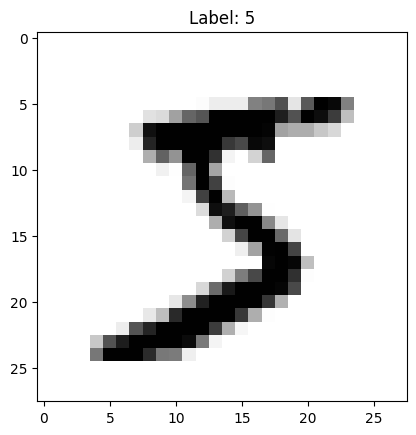

In [10]:
index = 0
image = x_train[index]
label = y_train[index]
print(type(image[0][0]))
print(image.shape)

plt.imshow(image, cmap=plt.cm.binary)
plt.title(f"Label: {label}")
plt.show()

## Preprocess Data for LeNet-5

Reshape the MNIST images to include a channel dimension (28, 28, 1) and normalize the pixel values to the range [0, 1]. Convert labels to one-hot encoded format.


In [11]:
import tensorflow as tf

# 1. Reshape images to include a channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# 2. Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Convert labels to one-hot encoded format
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"x_train shape after reshape and normalization: {x_train.shape}, dtype: {x_train.dtype}")
print(f"y_train shape after one-hot encoding: {y_train.shape}, dtype: {y_train.dtype}")
print(f"x_test shape after reshape and normalization: {x_test.shape}, dtype: {x_test.dtype}")
print(f"y_test shape after one-hot encoding: {y_test.shape}, dtype: {y_test.dtype}")
print("Data preprocessing completed successfully.")

x_train shape after reshape and normalization: (60000, 28, 28, 1), dtype: float32
y_train shape after one-hot encoding: (60000, 10), dtype: float64
x_test shape after reshape and normalization: (10000, 28, 28, 1), dtype: float32
y_test shape after one-hot encoding: (10000, 10), dtype: float64
Data preprocessing completed successfully.


## Define LeNet-5 Model

Construct the LeNet-5 CNN architecture using `tf.keras.Sequential`. This will include Conv2D, Activation, MaxPooling2D, Flatten, and Dense layers as specified by LeNet-5.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D,MaxPooling2D, Flatten, Dense, Input

# Initialize a Sequential model
model = Sequential([
    Input(shape=(28, 28, 1), name='input_layer'),

    # C1: Convolutional layer
    Conv2D(filters=6, kernel_size=(5, 5), activation='relu', name='conv1'),

    # S2: Pooling layer
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='pool1'),

    # C3: Convolutional layer
    Conv2D(filters=16, kernel_size=(5, 5), activation='relu', name='conv2'),

    # S4: Pooling layer
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='pool2'),

    # Flatten the output for the fully connected layers
    Flatten(name='flatten'),

    # F5: Fully connected layer
    Dense(units=120, activation='relu', name='dense1'),

    # F6: Fully connected layer
    Dense(units=84, activation='relu', name='dense2'),

    # Output layer
    Dense(units=10, activation='softmax', name='output_layer')
], name = 'LeNet-5')

# Print the model summary
model.summary()

print("LeNet-5 model architecture defined successfully.")

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

LeNet-5 model architecture defined successfully.


## Compile LeNet-5 Model

Compile the defined LeNet-5 model, specifying an optimizer (e.g., Adam), a loss function (e.g., `categorical_crossentropy` since labels are one-hot encoded), and metrics (e.g., accuracy).


In [13]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("LeNet-5 model compiled successfully.")

LeNet-5 model compiled successfully.


## Train LeNet-5 Model

Train the compiled LeNet-5 model using the preprocessed training data (`x_train`, `y_train`). Specify the number of epochs and batch size.


In [14]:
history = model.fit(x_train, y_train, epochs= 8, batch_size=32, validation_split=0.1)

print("LeNet-5 model training completed successfully.")

Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.8749 - loss: 0.4148 - val_accuracy: 0.9747 - val_loss: 0.0802
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9761 - loss: 0.0745 - val_accuracy: 0.9812 - val_loss: 0.0600
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9837 - loss: 0.0520 - val_accuracy: 0.9878 - val_loss: 0.0443
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9881 - loss: 0.0370 - val_accuracy: 0.9855 - val_loss: 0.0472
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9903 - loss: 0.0300 - val_accuracy: 0.9843 - val_loss: 0.0504
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9932 - loss: 0.0227 - val_accuracy: 0.9872 - val_loss: 0.0464
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9885 - val_loss: 0.0383
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9952 - loss: 0

#Evaluation of the Model

In [15]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0386
Test Accuracy: 0.9885


# Downloading the Model

## Inspect Model Layer Data Types and Shapes

Generate code to iterate through the model's layers and print their names, input shapes, and output shapes, providing insight into the type of data each layer processes.


In [16]:
print("Inspecting LeNet-5 model layers:")
for i, layer in enumerate(model.layers):
    print(f"\nLayer {i+1}:")
    print(f"  Name: {layer.name}")
    # Access input/output tensors and then their shape attribute
    # This assumes the layer has a single input and single output tensor
    # which is generally true for Sequential models after the model is built.
    try:
        input_tensor_shape = layer.input.shape
        output_tensor_shape = layer.output.shape
        print(f"  Input Shape: {input_tensor_shape}")
        print(f"  Output Shape: {output_tensor_shape}")
        print(f"  Number of Weights: {layer.count_params()}") # Added line for number of weights
    except AttributeError:
        print(f"  Could not retrieve tensor shapes for {layer.name}. This might happen if the layer is not yet connected or has a complex input/output structure.")

print("Layer inspection completed.")

Inspecting LeNet-5 model layers:

Layer 1:
  Name: conv1
  Input Shape: (None, 28, 28, 1)
  Output Shape: (None, 24, 24, 6)
  Number of Weights: 156

Layer 2:
  Name: pool1
  Input Shape: (None, 24, 24, 6)
  Output Shape: (None, 12, 12, 6)
  Number of Weights: 0

Layer 3:
  Name: conv2
  Input Shape: (None, 12, 12, 6)
  Output Shape: (None, 8, 8, 16)
  Number of Weights: 2416

Layer 4:
  Name: pool2
  Input Shape: (None, 8, 8, 16)
  Output Shape: (None, 4, 4, 16)
  Number of Weights: 0

Layer 5:
  Name: flatten
  Input Shape: (None, 4, 4, 16)
  Output Shape: (None, 256)
  Number of Weights: 0

Layer 6:
  Name: dense1
  Input Shape: (None, 256)
  Output Shape: (None, 120)
  Number of Weights: 30840

Layer 7:
  Name: dense2
  Input Shape: (None, 120)
  Output Shape: (None, 84)
  Number of Weights: 10164

Layer 8:
  Name: output_layer
  Input Shape: (None, 84)
  Output Shape: (None, 10)
  Number of Weights: 850
Layer inspection completed.


## Save the Model
Generate code to save the trained Keras model to a file. I will use the new Keras v3 format (.keras) by default, and also explain other common formats like HDF5 (.h5) and SavedModel format.


In [17]:
model.save('lenet5_mnist_model.keras')
print("LeNet-5 model saved successfully to 'lenet5_mnist_model.keras' (Keras v3 format).")

LeNet-5 model saved successfully to 'lenet5_mnist_model.keras' (Keras v3 format).


## Load the Model
Generate code to demonstrate how to load the saved model from the file, showing the process of re-uploading the model.


In [18]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('lenet5_mnist_model.keras')

# Print the summary of the loaded model to verify
loaded_model.summary()

print("LeNet-5 model loaded successfully from 'lenet5_mnist_model.keras'.")

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,280 (520.63 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,854 (347.09 KB)

LeNet-5 model loaded successfully from 'lenet5_mnist_model.keras'.
